In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
 
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb
 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load Data

In [2]:
df = pd.read_csv('../data/earthquake_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (782, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


## Create Threat Level Label from `sig`

In [3]:
# We engineer our target from the 'sig' (significance) column.
# Using `sig` over `alert` because:
#   - alert has 47% nulls → we'd lose half the dataset
#   - sig is available for all 782 records, no imputation needed
#   - sig is computed from magnitude, MMI, felt reports, and estimated impact
#     so it's a richer signal than alert alone
#
# Bins chosen from df.describe():
#   sig min=650, 25%=691, 50%=754, 75%=909, max=2910
#
#   LOW      : sig < 700   → minor event, localised impact
#   MEDIUM   : 700 ≤ sig < 800  → moderate, regional impact
#   HIGH     : 800 ≤ sig < 1000 → significant, national-level response
#   CRITICAL : sig ≥ 1000  → major disaster, international response
 
def assign_threat(sig):
    if   sig < 700:   return 'LOW'
    elif sig < 800:   return 'MEDIUM'
    elif sig < 1000:  return 'HIGH'
    else:             return 'CRITICAL'
 
df['threat_level'] = df['sig'].apply(assign_threat)
 
print("Threat level distribution:")
print(df['threat_level'].value_counts())
print(f"\nProportions:\n{df['threat_level'].value_counts(normalize=True).round(3)}")

Threat level distribution:
threat_level
MEDIUM      239
LOW         236
HIGH        165
CRITICAL    142
Name: count, dtype: int64

Proportions:
threat_level
MEDIUM      0.306
LOW         0.302
HIGH        0.211
CRITICAL    0.182
Name: proportion, dtype: float64


## Visualise the new label

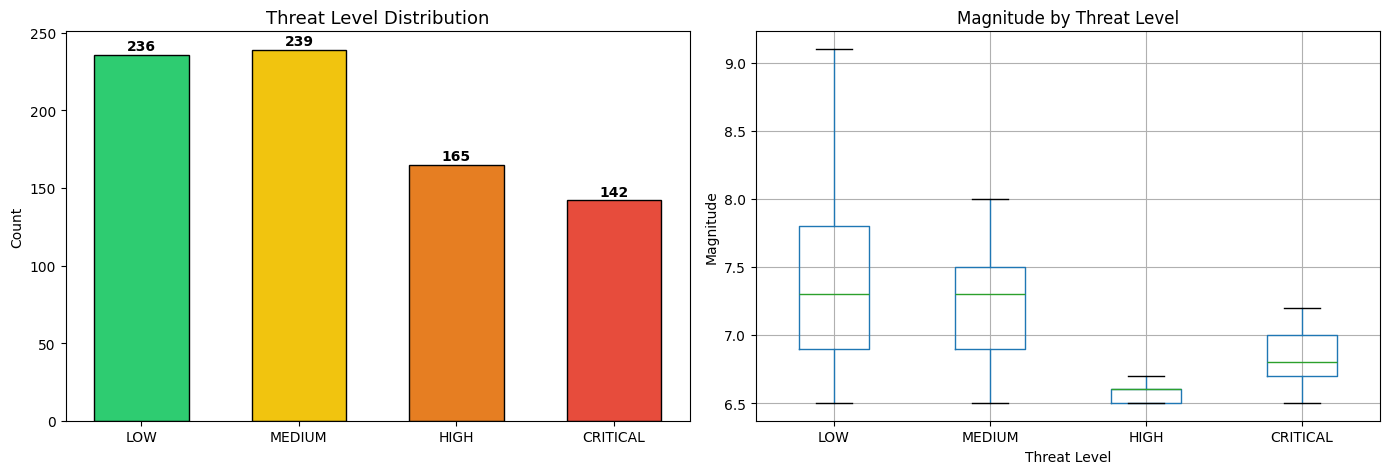

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
palette = {'LOW': '#2ecc71', 'MEDIUM': '#f1c40f', 'HIGH': '#e67e22', 'CRITICAL': '#e74c3c'}
 
# Class counts
counts = df['threat_level'].value_counts().reindex(order)
axes[0].bar(order, counts.values,
            color=[palette[o] for o in order], edgecolor='black', width=0.6)
axes[0].set_title('Threat Level Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
 
# Magnitude by threat level
df.boxplot(column='magnitude', by='threat_level',
           ax=axes[1], positions=[0, 1, 2, 3])
axes[1].set_xticklabels(order)
axes[1].set_title('Magnitude by Threat Level')
axes[1].set_xlabel('Threat Level')
axes[1].set_ylabel('Magnitude')
plt.suptitle('')
 
plt.tight_layout()
plt.show()

## Preprocessing

In [5]:
KEEP_COLS = ['magnitude', 'cdi', 'mmi', 'tsunami', 'sig',
             'nst', 'dmin', 'gap', 'magType', 'depth',
             'latitude', 'longitude', 'date_time', 'threat_level']
 
df = df[KEEP_COLS].copy()
 
# Parse date — cyclical encoding for month (better than raw integer)
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)
df['month_sin'] = np.sin(2 * np.pi * df['date_time'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date_time'].dt.month / 12)
df['year']      = df['date_time'].dt.year
df.drop('date_time', axis=1, inplace=True)
 
# One-hot encode magType (avoids ordinal assumption of LabelEncoder)
df = pd.get_dummies(df, columns=['magType'], drop_first=True)
 
# Encode target with a consistent label encoder (so we can decode predictions later)
le = LabelEncoder()
le.classes_ = np.array(order)           # fix the order: LOW=0, MEDIUM=1, HIGH=2, CRITICAL=3
df['threat_encoded'] = le.transform(df['threat_level'])
 
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")
 
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"Final shape: {df.shape}")

Label encoding:
  0 → LOW
  1 → MEDIUM
  2 → HIGH
  3 → CRITICAL

Null counts:
magnitude         0
cdi               0
mmi               0
tsunami           0
sig               0
nst               0
dmin              0
gap               0
depth             0
latitude          0
longitude         0
threat_level      0
month_sin         0
month_cos         0
year              0
magType_mb        0
magType_md        0
magType_ml        0
magType_ms        0
magType_mw        0
magType_mwb       0
magType_mwc       0
magType_mww       0
threat_encoded    0
dtype: int64
Final shape: (782, 24)


## Correlation of features with threat level

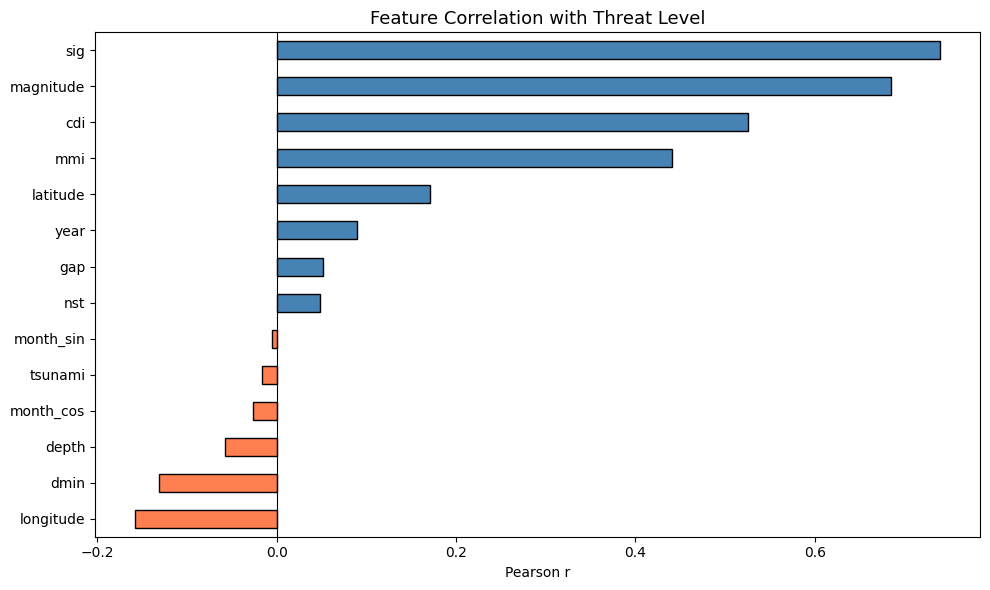

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr_threat = numeric_df.corr()['threat_encoded'].drop('threat_encoded').sort_values()
 
plt.figure(figsize=(10, 6))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_threat]
corr_threat.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Threat Level', fontsize=13)
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

## Train/Test Split

In [7]:
FEATURES = [c for c in df.columns if c not in ['threat_level', 'threat_encoded']]
TARGET   = 'threat_encoded'
 
X = df[FEATURES]
y = df[TARGET]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
# Scale after split — scaler fitted on train only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES)
 
print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"\nTrain class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")

Train: (625, 22) | Test: (157, 22)

Train class distribution:
threat_encoded
0    189
1    191
2    132
3    113
Name: count, dtype: int64


## Handle Class Imbalance with SMOTE

In [8]:
sm = SMOTE(random_state=42, k_neighbors=3)   # k=3 safer for small minority classes
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)
 
print(f"After SMOTE — shape: {X_train_res.shape}")
print(f"Class balance:\n{pd.Series(y_train_res).value_counts().sort_index()}")

After SMOTE — shape: (764, 22)
Class balance:
threat_encoded
0    191
1    191
2    191
3    191
Name: count, dtype: int64


## Train Multiple Models

In [9]:
# Add this to your Cell 1 imports:
# from imblearn.pipeline import Pipeline

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, objective='multi:softprob', num_class=4, eval_metric='mlogloss', random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

results = {}
target_names = list(le.classes_)   # ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']

for name, model in models.items():
    # 1. Fit the model on the resampled data for the final test set prediction
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)

    # 2. Use a Pipeline for Cross-Validation to prevent data leakage
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', model)
    ])
    
    # Notice we pass X_train_sc and y_train here, NOT the _res versions
    cv_acc = cross_val_score(pipeline, X_train_sc, y_train, 
                             cv=StratifiedKFold(5), scoring='accuracy').mean()

    results[name] = {'model': model, 'acc': acc, 'cv_acc': cv_acc, 'y_pred': y_pred}

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Accuracy   : {cv_acc:.4f}  (5-fold, on train set)")
    print(f"\n{classification_report(y_test, y_pred, target_names=target_names)}")


  Logistic Regression
  Test Accuracy : 0.9236
  CV Accuracy   : 0.8592  (5-fold, on train set)

              precision    recall  f1-score   support

         LOW       0.90      0.96      0.93        47
      MEDIUM       0.91      0.88      0.89        48
        HIGH       0.94      0.88      0.91        33
    CRITICAL       0.97      1.00      0.98        29

    accuracy                           0.92       157
   macro avg       0.93      0.93      0.93       157
weighted avg       0.92      0.92      0.92       157


  Decision Tree
  Test Accuracy : 0.9936
  CV Accuracy   : 1.0000  (5-fold, on train set)

              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00        47
      MEDIUM       1.00      1.00      1.00        48
        HIGH       1.00      0.97      0.98        33
    CRITICAL       0.97      1.00      0.98        29

    accuracy                           0.99       157
   macro avg       0.99      0.99      0.99      

## Visual Comparison

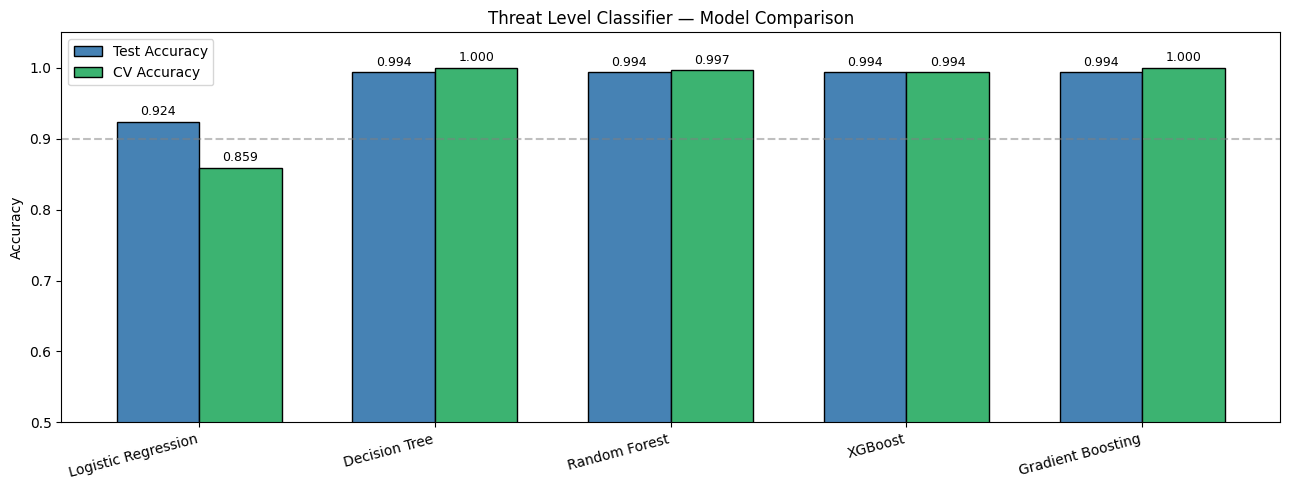

In [10]:
names   = list(results.keys())
accs    = [results[n]['acc']    for n in names]
cv_accs = [results[n]['cv_acc'] for n in names]
 
x = np.arange(len(names))
width = 0.35
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, accs,    width, label='Test Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, cv_accs, width, label='CV Accuracy',   color='mediumseagreen', edgecolor='black')
 
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Threat Level Classifier — Model Comparison')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
 
for i, (a, c) in enumerate(zip(accs, cv_accs)):
    ax.text(i - width/2, a + 0.005, f'{a:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, c + 0.005, f'{c:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.show()

## Best Model — Confusion Matrix

Best model: Decision Tree  (Test Accuracy = 0.9936)


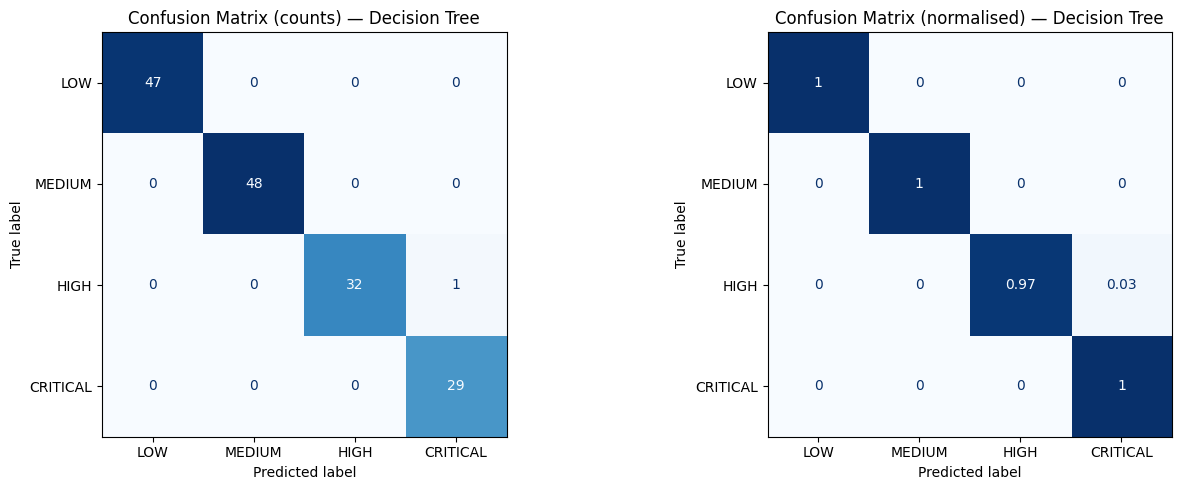

In [11]:
best_name = max(results, key=lambda n: results[n]['acc'])
best      = results[best_name]
print(f"Best model: {best_name}  (Test Accuracy = {best['acc']:.4f})")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Normalised confusion matrix (proportions)
cm     = confusion_matrix(y_test, best['y_pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
 
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (counts) — {best_name}')
 
ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=target_names).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix (normalised) — {best_name}')
 
plt.tight_layout()
plt.show()

## Feature Importance

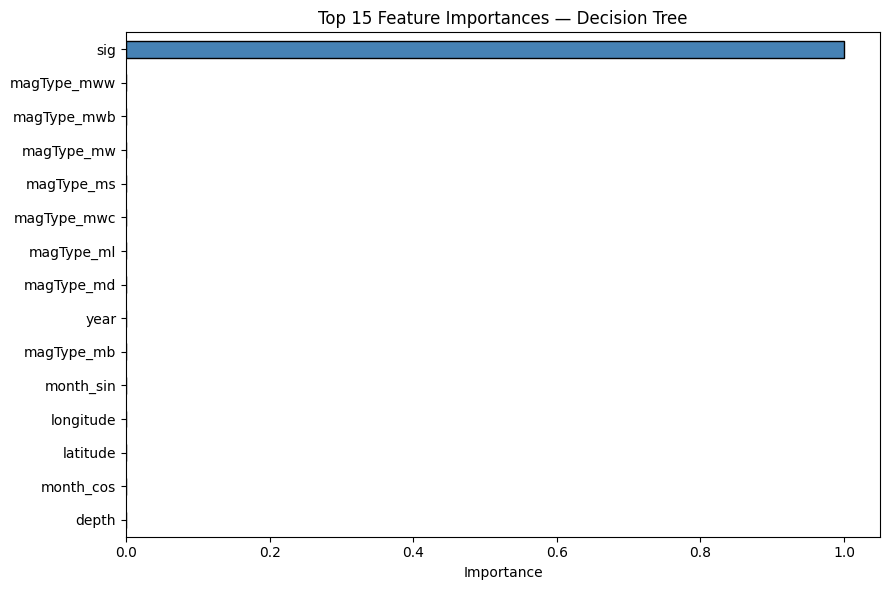

In [12]:
model_obj = best['model']
 
if hasattr(model_obj, 'feature_importances_'):
    imp = pd.Series(model_obj.feature_importances_, index=FEATURES).sort_values(ascending=True)
    top = imp.tail(15)
 
    plt.figure(figsize=(9, 6))
    top.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
 
elif hasattr(model_obj, 'coef_'):
    # For multinomial logistic, coef_ is (n_classes, n_features) — take mean abs
    imp = pd.Series(np.abs(model_obj.coef_).mean(axis=0), index=FEATURES).sort_values(ascending=True)
    top = imp.tail(15)
    plt.figure(figsize=(9, 6))
    top.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Top 15 Feature Coefficients (mean |value|) — {best_name}')
    plt.xlabel('Mean |Coefficient|')
    plt.tight_layout()
    plt.show()
 

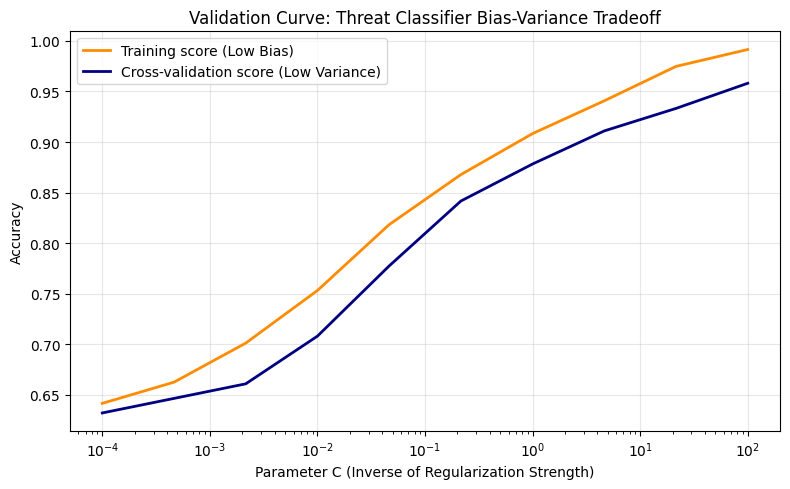

In [13]:
from sklearn.model_selection import validation_curve

# 1. Test different strengths of regularization (C)
# Small C = Strong regularization (prevents overfitting)
# Large C = Weak regularization (allows overfitting)
param_range = np.logspace(-4, 2, 10) 

train_scores, test_scores = validation_curve(
    LogisticRegression(penalty='l2', max_iter=1000, random_state=42),
    X_train_res, y_train_res, 
    param_name="C", 
    param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

# Calculate mean accuracy for training and validation sets
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 2. Plot the Bias-Variance Tradeoff Curve
plt.figure(figsize=(8, 5))
plt.semilogx(param_range, train_mean, label="Training score (Low Bias)", color="darkorange", lw=2)
plt.semilogx(param_range, test_mean, label="Cross-validation score (Low Variance)", color="navy", lw=2)
plt.title("Validation Curve: Threat Classifier Bias-Variance Tradeoff")
plt.xlabel("Parameter C (Inverse of Regularization Strength)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Best Model + Scaler + Encoder

In [14]:
os.makedirs('../models', exist_ok=True)
 
joblib.dump(best['model'], '../models/threat_model.pkl')
joblib.dump(scaler,        '../models/threat_scaler.pkl')
joblib.dump(le,            '../models/threat_label_encoder.pkl')
joblib.dump(FEATURES,      '../models/threat_features.pkl')
 
print(f"Saved threat_model.pkl  ({best_name})")
print(f"Saved threat_scaler.pkl")
print(f"Saved threat_label_encoder.pkl")
print(f"Saved threat_features.pkl")
print(f"\nClass labels: {list(le.classes_)}")
print(f"  → model outputs integers 0–3, decode with le.inverse_transform([pred])")
 
print(f"\nFinal model performance:")
print(f"  Test Accuracy : {best['acc']:.4f}")
print(f"  CV Accuracy   : {best['cv_acc']:.4f}")

Saved threat_model.pkl  (Decision Tree)
Saved threat_scaler.pkl
Saved threat_label_encoder.pkl
Saved threat_features.pkl

Class labels: [np.str_('LOW'), np.str_('MEDIUM'), np.str_('HIGH'), np.str_('CRITICAL')]
  → model outputs integers 0–3, decode with le.inverse_transform([pred])

Final model performance:
  Test Accuracy : 0.9936
  CV Accuracy   : 1.0000


## Quick Inference Test

In [15]:
# Shows how the AI notebook will call this model
 
def predict_threat(input_dict, model_path='../models/'):
    """
    input_dict keys must match FEATURES exactly.
    Example call — see below.
    """
    model    = joblib.load(model_path + 'threat_model.pkl')
    scaler   = joblib.load(model_path + 'threat_scaler.pkl')
    le       = joblib.load(model_path + 'threat_label_encoder.pkl')
    features = joblib.load(model_path + 'threat_features.pkl')
 
    row = pd.DataFrame([input_dict])[features]
    row_sc = scaler.transform(row)
    pred   = model.predict(row_sc)[0]
    return le.inverse_transform([pred])[0]
 
 
# Example
sample = X_test.iloc[0].to_dict()
print(f"Input features:\n{pd.Series(sample)}\n")
predicted = predict_threat(sample)
actual    = le.inverse_transform([y_test.iloc[0]])[0]
print(f"Sample prediction  : {predicted}")
print(f"Actual label       : {actual}")

Input features:
magnitude          7.1
cdi                  0
mmi                  5
tsunami              1
sig                776
nst                  0
dmin             7.043
gap               20.0
depth            133.0
latitude      -58.5446
longitude     -26.3856
month_sin         -0.0
month_cos          1.0
year              2018
magType_mb       False
magType_md       False
magType_ml       False
magType_ms       False
magType_mw       False
magType_mwb      False
magType_mwc      False
magType_mww       True
dtype: object

Sample prediction  : MEDIUM
Actual label       : MEDIUM
